In [13]:
!nvidia-smi

Sat Jun 21 11:52:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
import zipfile
import os

# Path to the zip file
zip_path = '/content/garbage.zip'

# Path where you want to extract
extract_path = '/content/'

# Create the extract folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")


Unzipped successfully!


In [15]:
!pip install gradio

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import gradio as gr
from PIL import Image

In [20]:
data_dir = '/content/TrashType_Image_Dataset'  # Update this path
batch_size = 32
img_height = 124
img_width = 124

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load test dataset (use the same directory or a separate test folder)
test_ds_eval = tf.keras.utils.image_dataset_from_directory(
    data_dir,  # Or a separate test folder path
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Found 2527 files belonging to 6 classes.


In [21]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_eval = test_ds_eval.cache().prefetch(buffer_size=AUTOTUNE)

In [24]:

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/TrashType_Image_Dataset',
    image_size=(124, 124),
    batch_size=32
)


class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)


Found 2527 files belonging to 6 classes.


In [26]:
# Create the model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(class_names), activation='softmax')  # Use class_names here
])


In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.7725 - loss: 0.6664 - val_accuracy: 0.9030 - val_loss: 0.2972
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8697 - loss: 0.3896 - val_accuracy: 0.9327 - val_loss: 0.1896
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9089 - loss: 0.2762 - val_accuracy: 0.9663 - val_loss: 0.1252
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9366 - loss: 0.2074 - val_accuracy: 0.9762 - val_loss: 0.1026
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9449 - loss: 0.1814 - val_accuracy: 0.9901 - val_loss: 0.0679
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9532 - loss: 0.1490 - val_accuracy: 0.9921 - val_loss: 0.0602
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9505 - loss: 0.1399 - val_accuracy: 0.9941 - val_loss: 0.0390
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9702 - loss: 0.1045 - val_accuracy: 0.9960 -

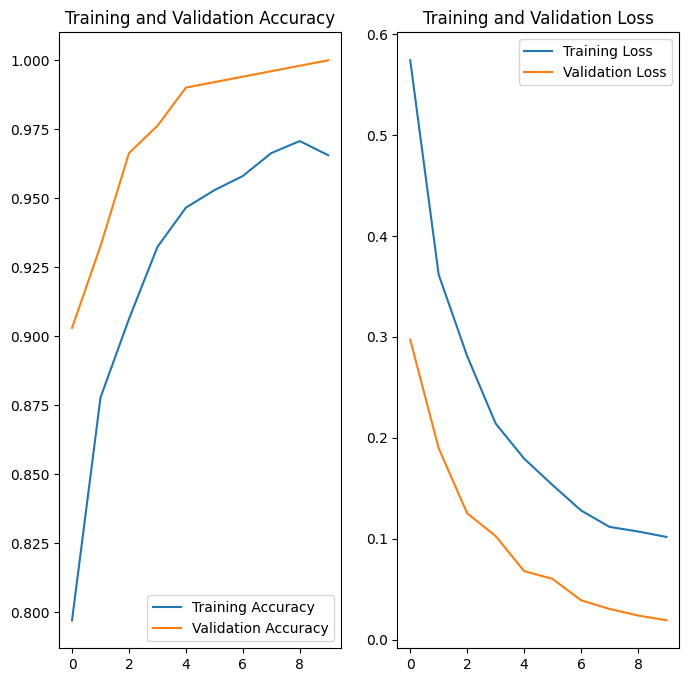

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [31]:
test_loss, test_accuracy = model.evaluate(test_ds_eval)
print(f"Test Accuracy: {test_accuracy:.2f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.9985 - loss: 0.0165
Test Accuracy: 1.00


In [34]:

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/TrashType_Image_Dataset',
    image_size=(124, 124),
    batch_size=32
)


class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_eval = test_ds_eval.cache().prefetch(buffer_size=AUTOTUNE)


Found 2527 files belonging to 6 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


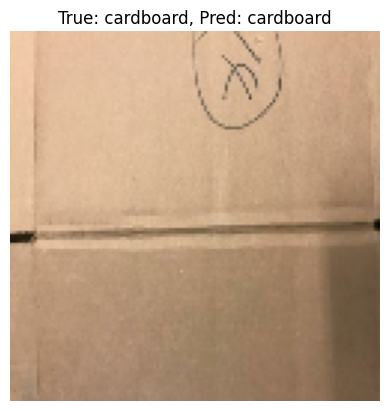

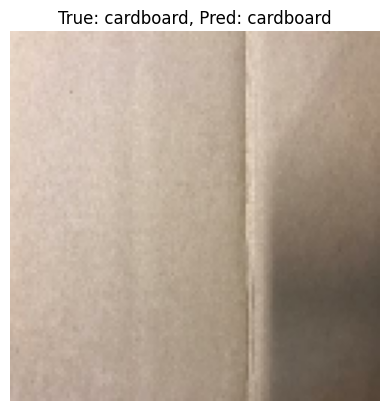

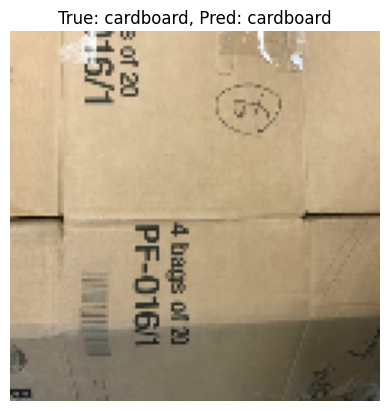

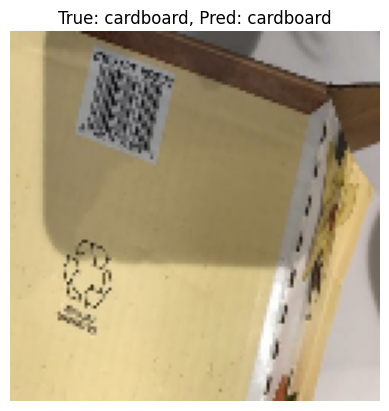

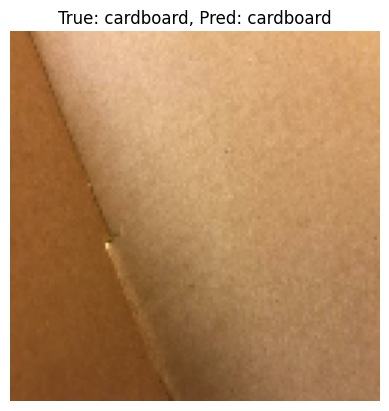

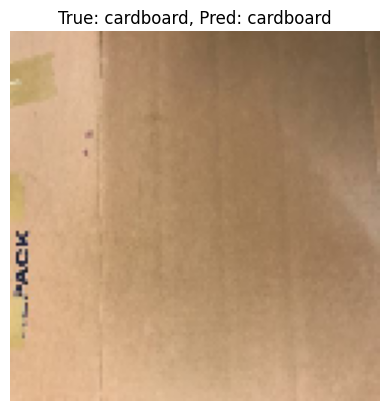

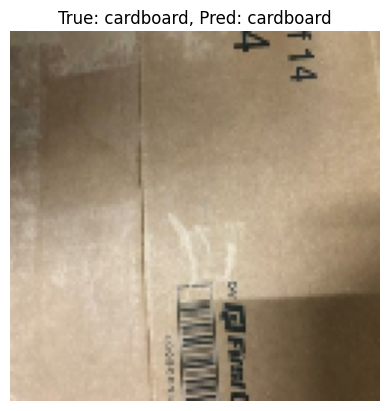

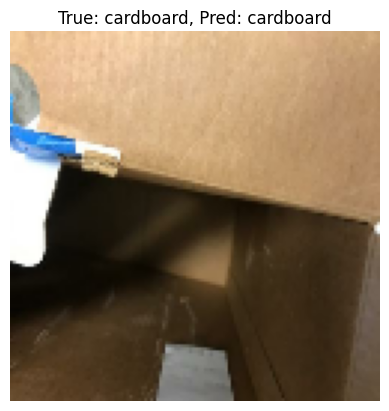

In [35]:
for images, labels in test_ds_eval.take(1):
    predictions = model.predict(images)
    pred_labels = tf.argmax(predictions, axis=1)
    for i in range(8):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}, Pred: {class_names[pred_labels[i]]}")
        plt.axis("off")
        plt.show()


In [37]:
model.save('/content/drive/MyDrive/EfficientNetV2B2.keras')